# Mean, Median & Mode
- They are called **measures of central tendency.** They are used to find a central qualifying value for a set of data.
  
## Mean
The average value of a dataset. Add all values together
and divide by how many there are.

**Biomedical example:** The mean dose of metformin
prescribed across 100 diabetic patients tells us the
typical dose — but does not tell us how much doses vary
between patients.

## Mean
**Definition:** The sum of all values divided by the
number of values. The arithmetic average.

**Formula:** Mean = sum of all values / count of values

**Biomedical example:** The mean plasma concentration
of a drug across 50 patients tells us the typical
exposure level in that population.

**When it misleads:** When data is skewed — for example,
a few patients with extremely high drug concentrations
will pull the mean upward, making it unrepresentative
of most patients.

## Variance
**Definition:** A measure of how spread out the values
in a dataset are from the mean. It is the average of
the squared differences from the mean.

**Formula:** Variance = sum of (each value - mean)²
             divided by the number of values

**Biomedical example:** A drug with high variance in
plasma concentration across patients means the drug
behaves very differently from person to person —
which is a major clinical concern for narrow
therapeutic index drugs like warfarin.

**Key insight:** Variance is always in squared units.
If doses are in mg, variance is in mg². This is why
we take the square root to get standard deviation.

## Standard Deviation
**Definition:** The square root of the variance.
It tells us, on average, how far individual values
sit from the mean — in the original units.

**Formula:** SD = square root of variance

**Biomedical example:** If the mean half-life of a
drug is 8 hours with SD of 1.5 hours, most patients
metabolise the drug somewhere between 6.5 and 9.5
hours. A large SD would mean dosing intervals are
harder to standardise.

**The key rule:** In a normal distribution,
approximately 68% of values fall within 1 SD of
the mean, 95% within 2 SD, 99.7% within 3 SD.


In [6]:
# A list of drug doses prescribed to 10 patients
doses = [500, 850, 250, 500, 1000, 500, 750, 250, 500, 850]

# - - - MEAN - - -
mean = sum(doses) / len(doses)
print(f"Mean dose: {mean}mg") 

# - - - MEDIAN - - -
sorted_doses = sorted(doses)
print(f"Sorted doses: {sorted_doses}")

n = len(sorted_doses)
if n % 2 == 1:
    median = sorted_doses[n // 2]
else:
    median = sorted_doses[n // 2 - 1] 
print(f"Median dose: {median}mg")

# - - - MODE - - -
from collections import Counter
counts = Counter(doses)
print(f"Value counts: {counts}")
mode = counts.most_common(1)[0][0]
print(f"Mode dose: {mode}mg")

# - - - SUMMARY - - -
print(f"\nSummary:")
print(f" Mean: {mean}mg")
print(f" Median: {median}mg")
print(f" Mode: {mode}mg")

Mean dose: 595.0mg
Sorted doses: [250, 250, 500, 500, 500, 500, 750, 850, 850, 1000]
Median dose: 500mg
Value counts: Counter({500: 4, 850: 2, 250: 2, 1000: 1, 750: 1})
Mode dose: 500mg

Summary:
 Mean: 595.0mg
 Median: 500mg
 Mode: 500mg


## What the numbers tell us
The mean is 595.0mg. The median is 500mg. The mode is 500mg.

The mean and median are close, this tells us that the distribution is close.

Clinically, the most prescribed dose is 500mg. If I were a pharmacist reviewing this precription pattern, I would note that this dose is generally effective for more members of the population.

## Stopped here - Day 2
Concepts covered: Mean, Median, Mode
Next: Standard Deviation and Variance
Weakest concept so far: coding with python. I have no idea what I am doing.
    

## Normal Distribution
- It is called a bell shaped curve because it is a **symmetrical** curve that looks like a bell.
- They are always centered on the average value.
- The Y axis shows the probability.
- The width of the curve is defined by the Standard deviation.
- The **mean** is the centre of the curve.
- The wider the curve, the shorter. The narrower the curve, the taller.
- Most things are normally distributed. This is due to the **Central Limit Theorem**(More on this later..)

**Definition:** A bell-shaped, symmetric distribution
where most values cluster around the mean and fewer
values appear as you move further away in either
direction.

**Key properties:**
- Mean, median, and mode are all equal
- Perfectly symmetric around the mean
- The further from the mean, the fewer values

**Biomedical example:** Drug plasma concentrations
in a population often follow a normal distribution —
most patients have concentrations near the mean
therapeutic level, with fewer patients at very low
or very high concentrations.

**Why it matters:** Many statistical methods assume
your data is normally distributed. Knowing this
shape tells you how to interpret SD meaningfully.

## Empirical Rule (68-95-99.7)%
- The probability of getting a value one standard deviation below or above the mean on the normal distribution curve is **68%,** the probability of getting a value on the curve two standard deviations below or above the mean is **95%,** the probability of finding a value three standard deviations below or above the mean is **99.7%.**

**Definition:** In a normal distribution:
- 68% of values fall within 1 SD of the mean
- 95% of values fall within 2 SD of the mean
- 99.7% of values fall within 3 SD of the mean

**Biomedical example:** A drug has mean half-life
of 8 hours and SD of 1.5 hours.
- 68% of patients: half-life between 6.5 and 9.5 hrs
- 95% of patients: half-life between 5 and 11 hrs
- 99.7% of patients: half-life between 2 and 14 hrs

**Clinical implication:** A patient with a half-life
outside the 95% range (below 5 or above 11 hours)
is statistically unusual and may need dose adjustment.

Mean half-life: 8.0 hours
SD: 1.5 hours
Within 1 SD: 81 patients (40.5%)
Within 2 SD: 161 patients (80.5%)
Within 3 SD: 200 patients (100.0%)


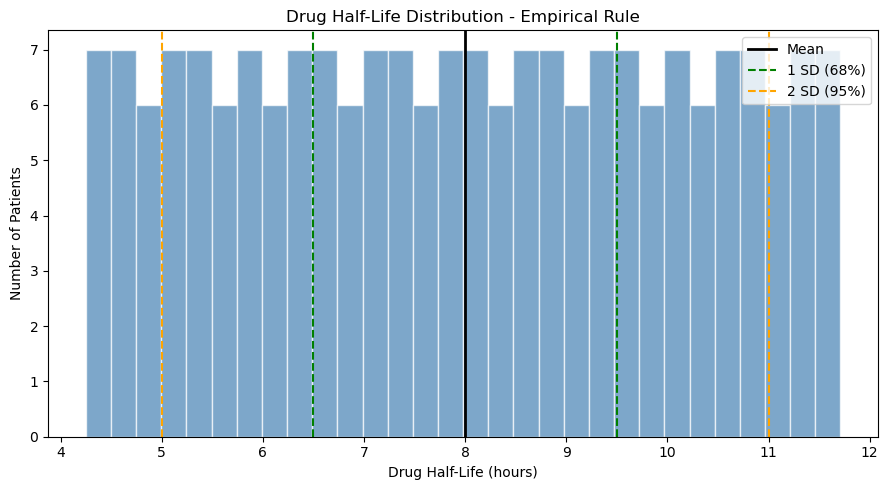

In [7]:
import math
import matplotlib.pyplot as plt

mean_halflife = 8.0
sd_halflife = 1.5

half_lives = []
for i in range(200):
    value = mean_halflife + sd_halflife * (i - 100) / 40
    half_lives.append(round(value, 2))

within_1sd = [v for v in half_lives if mean_halflife - sd_halflife <= v <= mean_halflife + sd_halflife]
within_2sd = [v for v in half_lives if mean_halflife - 2*sd_halflife <= v <= mean_halflife + 2*sd_halflife]
within_3sd = [v for v in half_lives if mean_halflife - 3*sd_halflife <= v <= mean_halflife + 3*sd_halflife]

print(f"Mean half-life: {mean_halflife} hours")
print(f"SD: {sd_halflife} hours")
print(f"Within 1 SD: {len(within_1sd)} patients ({len(within_1sd)/len(half_lives)*100:.1f}%)")
print(f"Within 2 SD: {len(within_2sd)} patients ({len(within_2sd)/len(half_lives)*100:.1f}%)")
print(f"Within 3 SD: {len(within_3sd)} patients ({len(within_3sd)/len(half_lives)*100:.1f}%)")

plt.figure(figsize=(9, 5))
plt.hist(half_lives, bins=30, color='steelblue', edgecolor='white', alpha=0.7)
plt.axvline(mean_halflife, color='black', linewidth=2, label='Mean')
plt.axvline(mean_halflife - sd_halflife, color='green', linestyle='--', label='1 SD (68%)')
plt.axvline(mean_halflife + sd_halflife, color='green', linestyle='--')
plt.axvline(mean_halflife - 2*sd_halflife, color='orange', linestyle='--', label='2 SD (95%)')
plt.axvline(mean_halflife + 2*sd_halflife, color='orange', linestyle='--')
plt.xlabel('Drug Half-Life (hours)')
plt.ylabel('Number of Patients')
plt.title('Drug Half-Life Distribution - Empirical Rule')
plt.legend()
plt.tight_layout()
plt.show()

## What I see in the chart

The distribution is SYMMETRIC.

The green lines (1 SD) capture approximately 68%
of patients in my simulation.

The orange lines (2 SD) capture approximately 95%
of patients.

A patient whose half-life falls outside the orange lines would be an unusual/outlier response compared with most patients. As a pharmacist, I would investigate possible causes such as abnormal pharmacokinetics, organ dysfunction (especially liver/kidney impairment), drug interactions, adherence issues, genetic differences in metabolism, or measurement error before making dosing decisions.

## Stopped here — Day 4
Concepts covered: Normal Distribution, Empirical Rule.

The chart helped my grasp of the concept to move from abstract to practical understanding. 

I still have questions about the **Central Limit Theorem.**

Next: Outliers, skewness, population vs sample, correlation

## Outlier

**Definition:** A value that falls far from the rest
of the data. Formally identified as any value more
than 2 standard deviations from the mean.

**Detection rule:** If a value is below (mean - 2×SD)
or above (mean + 2×SD), it is considered an outlier.

**Biomedical example:** A patient whose drug plasma
concentration is more than 2 SD above the mean
therapeutic level may be experiencing toxicity and
needs immediate clinical review.

**Why it matters:** Outliers can distort the mean
significantly. A single patient with an extreme
adverse reaction can pull the average in a dataset
if not identified and handled appropriately.

## Skewness
**Definition:** A measure of the asymmetry of a
distribution. When data is not symmetric around
the mean, it is skewed.

**Positive skew (right skew):** The tail stretches
to the right. Most values are low but a few extreme
high values pull the mean upward.
Example: Hospital length of stay — most patients
leave quickly but a few stay for months.

**Negative skew (left skew):** The tail stretches
to the left. Most values are high but a few extreme
low values pull the mean downward.
Example: Age at retirement — most people retire
around 60-65 but a few retire very early.

**Key insight:** When data is skewed, the median
is more representative than the mean — because
the mean gets pulled toward the tail.

## Population vs Sample
**Population:** The entire group you want to draw
conclusions about. Example: all diabetic patients
in Nigeria.

**Sample:** A subset of the population that you
actually collect data from. Example: 500 diabetic
patients from 3 hospitals in Lagos.

**Why it matters in research:** You almost never
have access to the full population. You work with
a sample and use statistics to make inferences
about the broader population — which is why sample
size and how you select participants matters enormously.

**Key implication:** When calculating SD from a
sample, you divide by (n-1) not n. This is called
Bessel's correction and makes the estimate more
accurate for the full population.

## Correlation
**Definition:** A measure of how strongly two
variables move together. Ranges from -1 to +1.

**Positive correlation (+1):** As one variable
increases, the other increases.
Example: Higher dose → higher plasma concentration.

**Negative correlation (-1):** As one variable
increases, the other decreases.
Example: Higher drug clearance → lower plasma
concentration.

**No correlation (0):** No relationship between
the two variables.

**THE MOST IMPORTANT POINT:** Correlation does NOT
mean causation. Two variables can move together
for entirely unrelated reasons. Example: ice cream
sales and drowning rates both rise in summer —
but ice cream does not cause drowning. Always
ask: is there a biological mechanism that explains
this relationship?

**NOTES:**
- In real biological and medical data, perfect correlations essentially never happen. Because human bodies are not machines — they are complex, variable, and influenced by hundreds of factors simultaneously.
The only place you see perfect correlations:

- Mathematical relationships — like the correlation between a number and itself is always exactly +1
Simulated or synthetic data created for teaching purposes
When someone has made an error in their analysis

- If a researcher publishes a correlation of exactly +1.0 between two biological variables — be suspicious. It almost certainly means something went wrong.

- A weak correlation in medicine does not always mean unimportant. A correlation of +0.3 between a cheap, widely available drug and reduced mortality across millions of patients could be one of the most important findings in public health that year. Statistical strength and clinical significance are not the same thing.

- There is a formula to calculate correlation but there's almost no need to memorise it as python calculates correlations on request.

## Why Statistics Matters in Computational Pharmacology

Statistics is not just mathematics — it is the language
through which drug data becomes clinical meaning.

Standard deviation tells us about outcomes across a 
number of patients. When SD is small, it means similar 
outcomes across patients. When SD is large, it means 
a wide variety of outcomes across patients. Narrow 
therapeutic index drugs can be unsafe if, when 
experimented on, they show a large SD — because a 
small difference in concentration can cause a switch 
from therapeutic to toxic.

Outliers matter in clinical trial data because an 
extreme value could be a signal rather than noise. 
Ignoring an outlier could mean ignoring a potential 
adverse drug reaction or an underlying problem. For 
instance, a patient in a paracetamol trial whose 
plasma concentration is 3 SD above the mean could 
be experiencing early hepatotoxicity — flagging that 
outlier could prevent liver failure.

Correlation is one of the most misunderstood tools 
in biomedical research. Just because two variables 
move together does not mean one is an effect of the 
other. A proper investigation must be done to 
determine causation and not just correlation between 
variables. For example, sicker patients take more 
medications and also have worse outcomes — but it is 
the underlying illness causing both, not the 
medications themselves.

In computational pharmacology, these three concepts — 
standard deviation, outliers, and correlation — form 
the foundation of every honest analysis.

In [1]:
import math
from collections import Counter

# A dataset of paracetamol doses prescribed to 15 patients
doses = [500, 850, 250, 500, 1000, 500, 750, 
         250, 500, 850, 600, 450, 500, 1200, 480]

# MEAN
mean = sum(doses) / len(doses)

# MEDIAN
sorted_doses = sorted(doses)
n = len(sorted_doses)
if n % 2 == 1:
    median = sorted_doses[n // 2]
else:
    median = (sorted_doses[n//2 - 1] + sorted_doses[n//2]) / 2

# MODE
counts = Counter(doses)
mode = counts.most_common(1)[0][0]

# VARIANCE AND SD
variance = sum((x - mean)**2 for x in doses) / len(doses)
sd = math.sqrt(variance)

# OUTLIER BOUNDARIES
lower = mean - 2 * sd
upper = mean + 2 * sd
outliers = [x for x in doses if x < lower or x > upper]

print("=" * 40)
print("PARACETAMOL DOSE STATISTICS")
print("=" * 40)
print(f"Mean:      {mean:.1f}mg")
print(f"Median:    {median}mg")
print(f"Mode:      {mode}mg")
print(f"Variance:  {variance:.1f}")
print(f"SD:        {sd:.1f}mg")
print(f"Range:     {min(doses)}mg to {max(doses)}mg")
print(f"")
print(f"Outlier boundaries:")
print(f"  Lower: {lower:.1f}mg")
print(f"  Upper: {upper:.1f}mg")
print(f"  Outliers found: {outliers}")
print(f"")
print(f"68% of doses expected between:")
print(f"  {mean - sd:.1f}mg and {mean + sd:.1f}mg")
print(f"95% of doses expected between:")
print(f"  {mean - 2*sd:.1f}mg and {mean + 2*sd:.1f}mg")

PARACETAMOL DOSE STATISTICS
Mean:      612.0mg
Median:    500mg
Mode:      500mg
Variance:  66482.7
SD:        257.8mg
Range:     250mg to 1200mg

Outlier boundaries:
  Lower: 96.3mg
  Upper: 1127.7mg
  Outliers found: [1200]

68% of doses expected between:
  354.2mg and 869.8mg
95% of doses expected between:
  96.3mg and 1127.7mg


## Consolidation Analysis — What This Tells Us

The mean dose is 612mg and the median is 500mg.
The mean is higher than the median, which suggests the distribution is positively skewed — pulled by higher extreme values.

The SD is 257.8mg, meaning most patients receive between 354.2mg and 864.8mg.

Outliers found: 1200mg. A dose of 1200mg exceeds the standard maximum single dose of paracetamol (1000mg). This patient warrants clinical review for potential hepatotoxicity risk, possible prescribing error, or an undocumented clinical reason for the higher dose.

An SD of 257.8mg would be deeply concerning for a narrow therapeutic index drug — because a difference of even 100mg can shift a patient from therapeutic to toxic. This level of variation in dosing would require urgent review and likely individual dose titration for every patient.

